In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('urban_lifestyle_impact_dataset.csv')
df.head()

,daily_travel_time,vehicle_ownership,location_type,nearby_industries,green_space_access,home_air_quality,work_location_type,smoker_in_household,noise_pollution_level,use_of_air_purifiers,awareness_level,years_in_location,pollution_exposure_score,risk_category
0,54.9,NaN,Semi-Urban,1.0,Moderate,65.4,Factory,False,34.9,True,NaN,28.0,32.50,Medium
1,42.2,Public Only,Semi-Urban,5.0,High,41.8,NaN,False,89.6,False,Low,30.0,70.58,High
2,58.0,NaN,Urban,1.0,Low,65.0,Remote,False,53.6,False,Medium,26.0,41.57,Medium
3,75.5,Car,Semi-Urban,2.0,Moderate,64.4,Remote,False,27.1,False,High,22.0,43.97,Medium
4,40.3,NaN,Semi-Urban,1.0,High,52.9,Factory,True,27.2,False,Medium,24.0,38.08,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   daily_travel_time         8876 non-null   float64
 1   vehicle_ownership         6836 non-null   str    
 2   location_type             10000 non-null  str    
 3   nearby_industries         9205 non-null   float64
 4   green_space_access        9440 non-null   str    
 5   home_air_quality          10000 non-null  float64
 6   work_location_type        9347 non-null   str    
 7   smoker_in_household       10000 non-null  bool   
 8   noise_pollution_level     10000 non-null  float64
 9   use_of_air_purifiers      10000 non-null  bool   
 10  awareness_level           8985 non-null   str    
 11  years_in_location         9480 non-null   float64
 12  pollution_exposure_score  10000 non-null  float64
 13  risk_category             10000 non-null  str    
dtypes: bool(2), float6

In [5]:
df.describe()

,daily_travel_time,nearby_industries,home_air_quality,noise_pollution_level,years_in_location,pollution_exposure_score
count,4179.000000,4179.000000,4179.000000,4179.000000,4179.000000,4179.000000
mean,44.968605,2.001196,60.375975,49.903709,20.584590,44.855815
std,19.908435,1.433127,15.069679,20.024030,11.541928,12.112984
min,0.000000,0.000000,8.700000,0.000000,1.000000,7.040000
25%,31.300000,1.000000,50.200000,37.100000,11.000000,36.025000
50%,45.000000,2.000000,60.400000,49.800000,21.000000,44.490000
75%,58.400000,3.000000,70.800000,63.000000,31.000000,52.980000
max,122.100000,10.000000,100.000000,100.000000,40.000000,98.400000


In [6]:
df['risk_category'].value_counts()

risk_category
Medium    3639
Low        438
High       102
Name: count, dtype: int64

<Axes: xlabel='risk_category'>

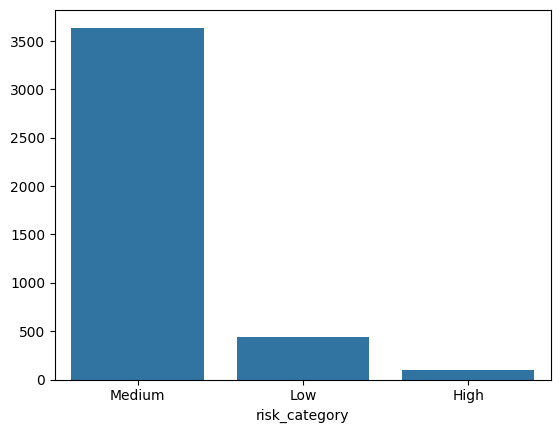

In [7]:
sns.barplot(x=df['risk_category'].value_counts().index, y=df['risk_category'].value_counts().values)

In [8]:
from sklearn.preprocessing import LabelEncoder

label_column = 'risk_category'
label_encoder = LabelEncoder()
label_encoder.fit(df[label_column])
labels = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
df[label_column] = label_encoder.transform(df[label_column])
labels

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

In [9]:
string_columns = df.select_dtypes(include=['str']).columns

df = pd.get_dummies(df, columns=string_columns, drop_first=True)
bool_columns = df.select_dtypes(include=['bool']).columns
df[bool_columns] = df[bool_columns].astype(int)
df.info()

<class 'pandas.DataFrame'>
Index: 4179 entries, 3 to 9999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   daily_travel_time              4179 non-null   float64
 1   nearby_industries              4179 non-null   float64
 2   home_air_quality               4179 non-null   float64
 3   smoker_in_household            4179 non-null   int64  
 4   noise_pollution_level          4179 non-null   float64
 5   use_of_air_purifiers           4179 non-null   int64  
 6   years_in_location              4179 non-null   float64
 7   pollution_exposure_score       4179 non-null   float64
 8   risk_category                  4179 non-null   int64  
 9   vehicle_ownership_Public Only  4179 non-null   int64  
 10  vehicle_ownership_Two-wheeler  4179 non-null   int64  
 11  location_type_Semi-Urban       4179 non-null   int64  
 12  location_type_Urban            4179 non-null   int64  
 13  gree

<Axes: >

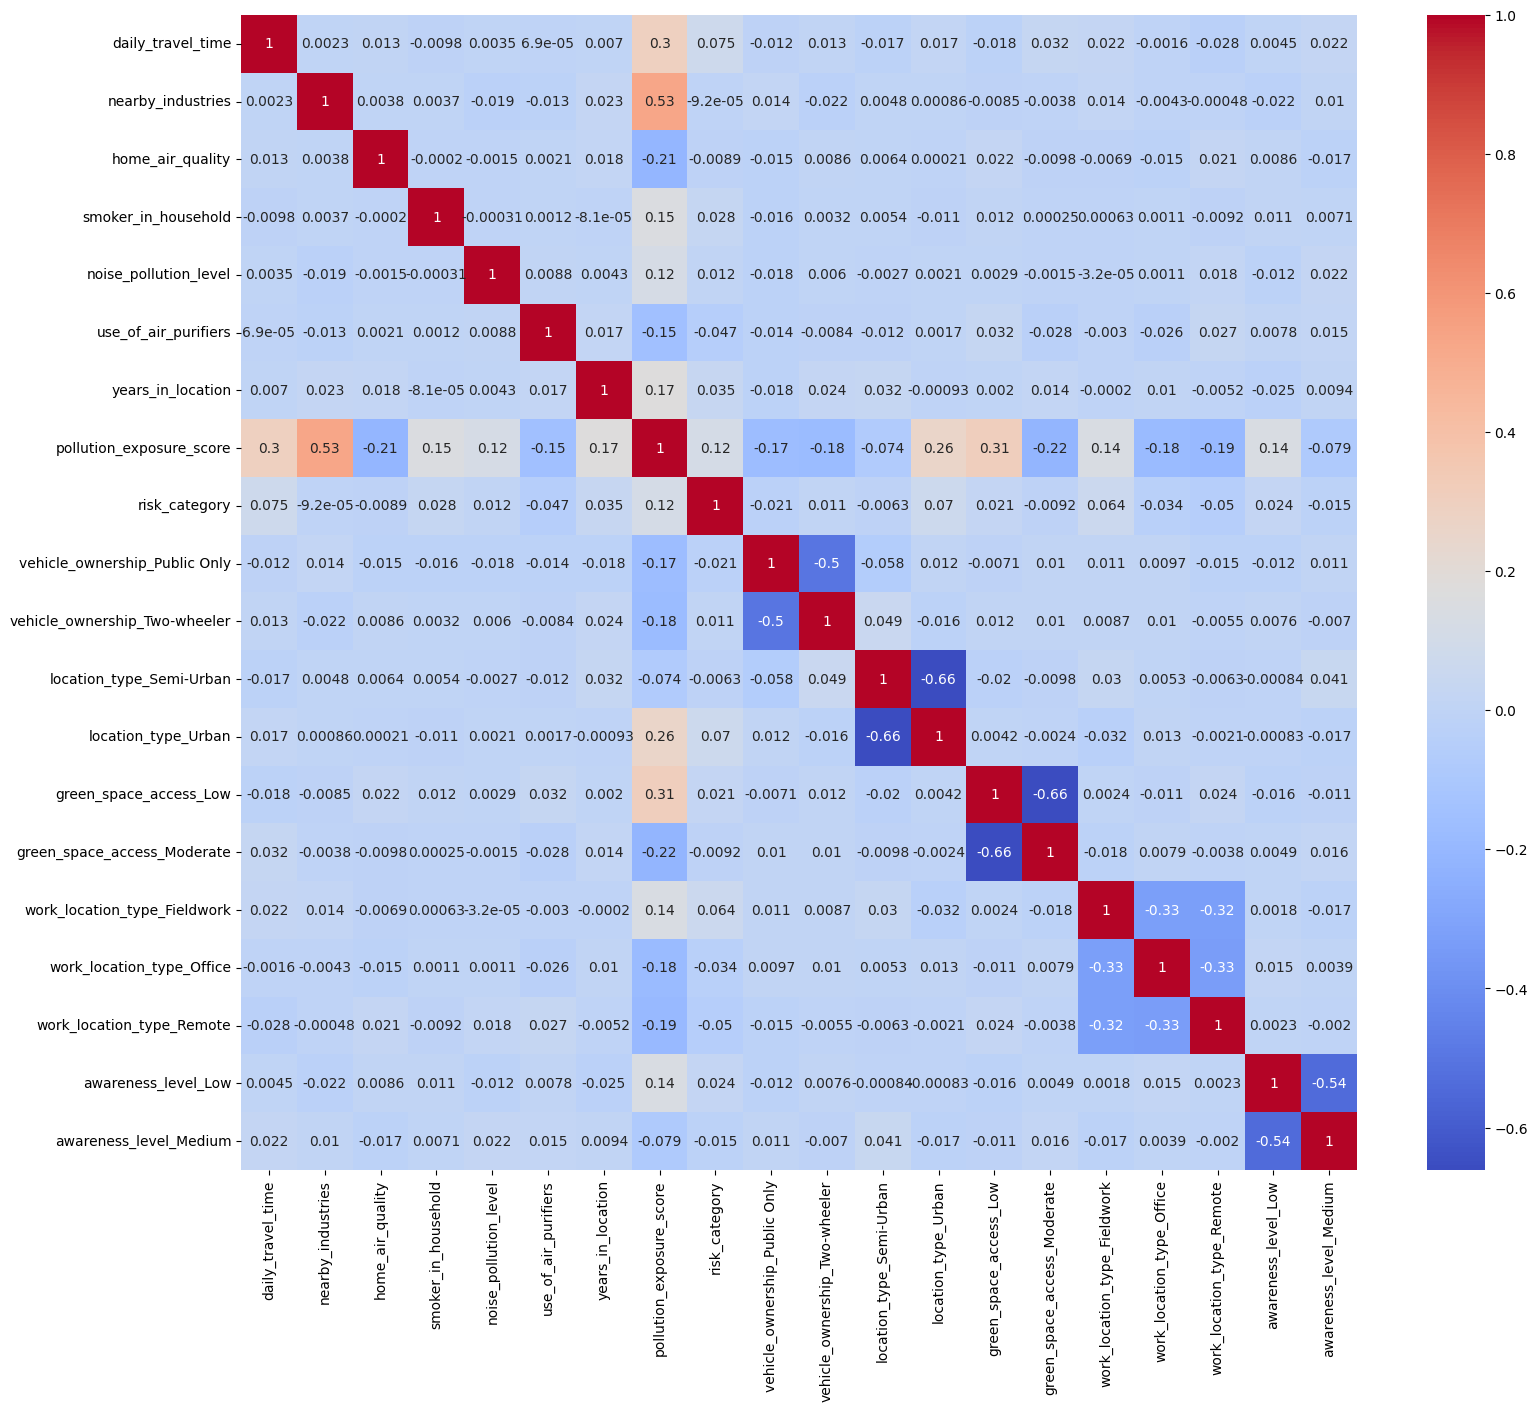

In [10]:
plt.figure(figsize=(18, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

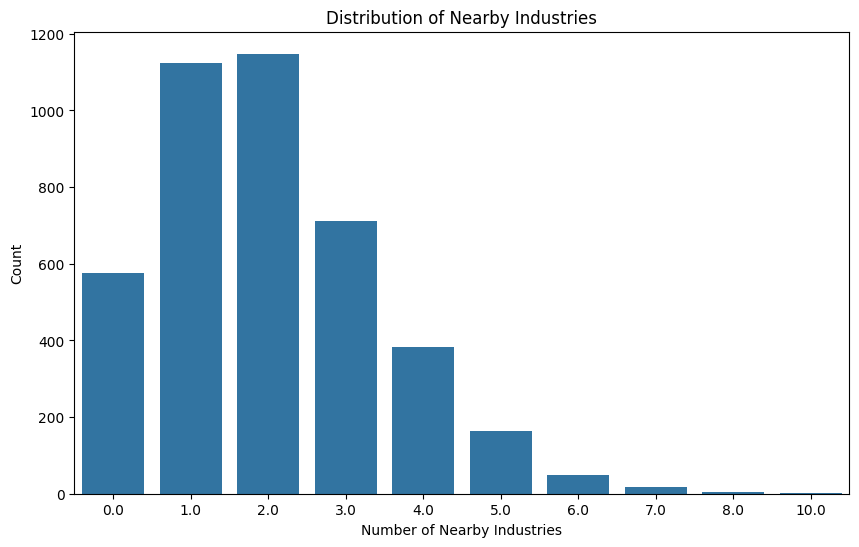

In [11]:
a = df['nearby_industries'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=a.index, y=a.values)
plt.xlabel('Number of Nearby Industries')
plt.ylabel('Count')
plt.title('Distribution of Nearby Industries')
plt.show()

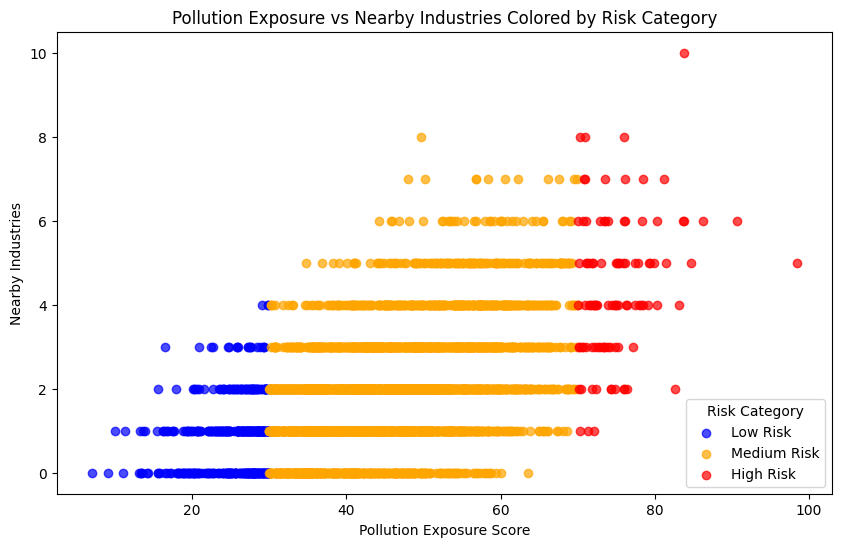

In [12]:
plt.figure(figsize=(10, 6))
low_risk = df[df['risk_category'] == labels['Low']]
medium_risk = df[df['risk_category'] == labels['Medium']]
high_risk = df[df['risk_category'] == labels['High']]
plt.scatter(low_risk['pollution_exposure_score'], low_risk['nearby_industries'], c='blue', label='Low Risk', alpha=0.7)
plt.scatter(medium_risk['pollution_exposure_score'], medium_risk['nearby_industries'], c='orange', label='Medium Risk', alpha=0.7)
plt.scatter(high_risk['pollution_exposure_score'], high_risk['nearby_industries'], c='red', label='High Risk', alpha=0.7)
plt.legend(title='Risk Category', loc='lower right')
plt.xlabel('Pollution Exposure Score')
plt.ylabel('Nearby Industries')
plt.title('Pollution Exposure vs Nearby Industries Colored by Risk Category')
plt.show()

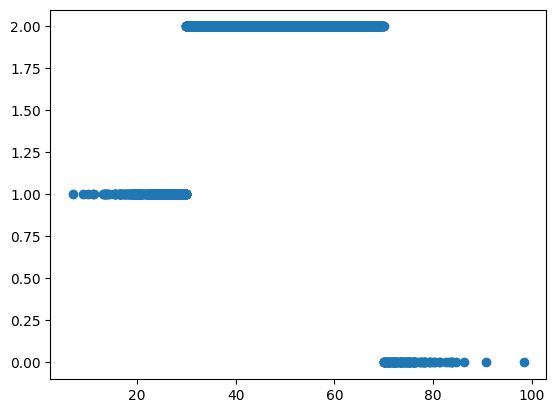

In [13]:
plt.scatter(df['pollution_exposure_score'], df['risk_category'])

In [14]:
from dataclasses import dataclass
from typing import Any


@dataclass
class ModelEvaluationResult:
    model: Any
    mse: float
    confusion_matrix: np.ndarray
    r2: float
    roc: float
    class_1_precision: float
    class_1_recall: float
    class_1_f1: float
    class_1_support: int
    class_2_precision: float
    class_2_recall: float
    class_2_f1: float
    class_2_support: int
    class_3_precision: float
    class_3_recall: float
    class_3_f1: float
    class_3_support: int


In [15]:
from sklearn.metrics import classification_report, mean_squared_error, confusion_matrix, roc_auc_score, r2_score

def fit_and_evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    class_1_precision = report['0']['precision']
    class_1_recall = report['0']['recall']
    class_1_f1 = report['0']['f1-score']
    class_1_support = report['0']['support']
    class_2_precision = report['1']['precision']
    class_2_recall = report['1']['recall']
    class_2_f1 = report['1']['f1-score']
    class_2_support = report['1']['support']
    class_3_precision = report['2']['precision']
    class_3_recall = report['2']['recall']
    class_3_f1 = report['2']['f1-score']
    class_3_support = report['2']['support']
    _confusion_matrix = confusion_matrix(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    roc = 0 # roc_auc_score(y_test, y_pred)

    return ModelEvaluationResult(
        model=model,
        mse=mse,
        confusion_matrix=_confusion_matrix,
        r2=r2,
        roc=roc,
        class_1_precision=class_1_precision,
        class_1_recall=class_1_recall,
        class_1_f1=class_1_f1,
        class_1_support=class_1_support,
        class_2_precision=class_2_precision,
        class_2_recall=class_2_recall,
        class_2_f1=class_2_f1,
        class_2_support=class_2_support,
        class_3_precision=class_3_precision,
        class_3_recall=class_3_recall,
        class_3_f1=class_3_f1,
        class_3_support=class_3_support
    )

In [29]:
from dataclasses import asdict
from sklearn.impute import KNNImputer
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.base import clone


class ModelTester:
    def __init__(self, X, y, test_size=0.2, random_state=42):
        self.results = []
        self.X = X
        self.y = y
        self.test_size = test_size
        self.random_state = random_state
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=self.test_size, random_state=self.random_state, stratify=self.y
        )

    def resample_data(self, method='oversample'):
        if method == 'oversample':
            # make all classes have the same number of samples as the majority class
            value_counts = self.y_train.value_counts()
            majority_class = value_counts.idxmax()
            minority_classes = value_counts.index[value_counts.index != majority_class]
            ratios = value_counts[majority_class] / value_counts[minority_classes]
            for minority_class in minority_classes:
                ratio = ratios[minority_class]
                n_samples = int(len(self.y_train) * ratio)
                X_minority = self.X_train[self.y_train == minority_class]
                y_minority = self.y_train[self.y_train == minority_class]
                X_resampled, y_resampled = resample(X_minority, y_minority, replace=True, n_samples=n_samples, random_state=self.random_state)
                self.X_train = pd.concat([self.X_train, X_resampled])
                self.y_train = pd.concat([self.y_train, y_resampled])
            print(f"After oversampling, class distribution:\n{self.y_train.value_counts()}")
            # minority_class = value_counts.idxmin()
            # ratio = value_counts[majority_class] / value_counts[minority_class]
            # n_samples = int(len(self.y_train) * ratio)
            self.X_train, self.y_train = resample(self.X_train, self.y_train, replace=True, random_state=self.random_state)
        elif method == 'undersample':
            df = pd.concat([self.X_train, self.y_train], axis=1)
            value_counts = self.y_train.value_counts()
            assert len(value_counts) == 2, "Undersampling only works for binary classification"
            majority_class = value_counts.idxmax()
            minority_class = value_counts.idxmin()
            majority_df = df[df[self.y_train.name] == majority_class]
            minority_df = df[df[self.y_train.name] == minority_class]
            majority_df_downsampled = majority_df.sample(n=len(minority_df), random_state=self.random_state)
            df_downsampled = pd.concat([majority_df_downsampled, minority_df])
            self.X_train = df_downsampled.drop(columns=[self.y_train.name])
            self.y_train = df_downsampled[self.y_train.name]
        elif method == 'hybrid':
            # first undersample the majority class, then oversample the minority classes to match the new majority class size
            df = pd.concat([self.X_train, self.y_train], axis=1)
            value_counts = self.y_train.value_counts()
            majority_class = value_counts.idxmax()
            minority_classes = value_counts.index[value_counts.index != majority_class]
            # undersample the majority class
            majority_df = df[df[self.y_train.name] == majority_class]
            minority_df = df[df[self.y_train.name] == minority_class]
            ratio = value_counts[majority_class] / value_counts[minority_classes].min()
            majority_df_downsampled = majority_df.sample(n=int(len(minority_df) * 0.5 * ratio), random_state=self.random_state)
            df_downsampled = pd.concat([majority_df_downsampled, minority_df])
            self.X_train = df_downsampled.drop(columns=[self.y_train.name])
            self.y_train = df_downsampled[self.y_train.name]
            # oversample the minority classes to match the new majority class size
            value_counts = self.y_train.value_counts()
            majority_class = value_counts.idxmax()
            minority_classes = value_counts.index[value_counts.index != majority_class]
            ratios = value_counts[majority_class] / value_counts[minority_classes]
            for minority_class in minority_classes:
                ratio = ratios[minority_class]
                n_samples = int(len(self.y_train) * ratio)
                X_minority = self.X_train[self.y_train == minority_class]
                y_minority = self.y_train[self.y_train == minority_class]
                # concatenate the oversampled minority class with the rest of the data
                self.X_train = pd.concat([self.X_train] + [X_minority] * len(minority_classes))
                self.y_train = pd.concat([self.y_train] + [y_minority] * len(minority_classes))
        else:
            raise ValueError("Method must be 'oversample' or 'undersample'")

    def _oversample(self, X, y):
        value_counts = y.value_counts()
        majority_class = value_counts.idxmax()
        minority_classes = value_counts.index[value_counts.index != majority_class]
        ratios = value_counts[majority_class] / value_counts[minority_classes]
        for minority_class in minority_classes:
            ratio = ratios[minority_class]
            n_samples = int(len(y) * ratio)
            X_minority = X[y == minority_class]
            y_minority = y[y == minority_class]
            X_resampled, y_resampled = resample(X_minority, y_minority, replace=True, n_samples=n_samples, random_state=self.random_state)
            X = pd.concat([X, X_resampled])
            y = pd.concat([y, y_resampled])
        return X, y

    def _undersample(self, X, y, target_size=None):
        df = pd.concat([X, y], axis=1)
        value_counts = y.value_counts()
        majority_class = value_counts.idxmax()
        minority_class = value_counts.idxmin()
        majority_df = df[df[y.name] == majority_class]
        minority_df = df[df[y.name] == minority_class]
        if target_size is not None:
            majority_df_downsampled = majority_df.sample(n=target_size, random_state=self.random_state)
        else:
            majority_df_downsampled = majority_df.sample(n=len(minority_df), random_state=self.random_state)
        df_downsampled = pd.concat([majority_df_downsampled, minority_df])
        X_downsampled = df_downsampled.drop(columns=[y.name])
        y_downsampled = df_downsampled[y.name]
        return X_downsampled, y_downsampled

    def test_model(self, model, k_fold=False, oversample=False, undersample=False, class_weight=None):
        if class_weight:
            if hasattr(model, 'class_weight'):
                value_counts = self.y_train.value_counts()
                classes = np.unique(self.y_train)
                weights = compute_class_weight(class_weight='balanced', classes=classes, y=self.y_train)
                cw = dict(zip(classes, weights))
                model.set_params(class_weight=cw)

        if k_fold:
            splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)
            X_data = self.X_train
            y_data = self.y_train
            for train_index, test_index in splitter.split(X_data, y_data):
                imputer = KNNImputer(n_neighbors=5)
                X_train_kf, X_test_kf = X_data.iloc[train_index], X_data.iloc[test_index]
                y_train_kf, y_test_kf = y_data.iloc[train_index], y_data.iloc[test_index]

                X_train_kf = imputer.fit_transform(X_train_kf)
                X_test_kf = imputer.transform(X_test_kf)

                if oversample:
                    X_train_kf, y_train_kf = self._oversample_fold(X_train_kf, y_train_kf)
                elif undersample:
                    X_train_kf, y_train_kf = self._undersample(X_train_kf, y_train_kf, target_size=int(len(y_train_kf) / 2))

                result = fit_and_evaluate_model(clone(model), X_train_kf, y_train_kf, X_test_kf, y_test_kf)
                self.results.append(result)
        else:
            if oversample:
                X_train, y_train = self._oversample(self.X_train, self.y_train)
            elif undersample:
                X_train, y_train = self._undersample(self.X_train, self.y_train, target_size=int(len(self.y_train) / 2))
            else:
                X_train, y_train = self.X_train, self.y_train

            result = fit_and_evaluate_model(model, X_train, y_train, self.X_test, self.y_test)
            self.results.append(result)

    def get_results_dataframe(self):
        results_df = pd.DataFrame([asdict(result) for result in self.results])
        return results_df


In [17]:
from pprint import pprint

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from dataclasses import asdict

models = [
    DecisionTreeClassifier(random_state=42),
    Perceptron(random_state=42, max_iter=1_000, penalty='l2', alpha=0.01, eta0=0.1),
    RandomForestClassifier(random_state=42),
    LogisticRegression(random_state=42, max_iter=1_000),
    LinearSVC(random_state=42, max_iter=1_000),
    GaussianNB(),
    AdaBoostClassifier(random_state=42),
]

X, y = df.drop(columns=['risk_category', 'pollution_exposure_score']), df['risk_category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
results = {}
for model in models:
    result = fit_and_evaluate_model(model, X_train, y_train, X_test, y_test)
    # pprint(result)
    # print("\n" + "="*80 + "\n")
    results[model.__class__.__name__] = result

# tester = ModelTester(X, y)
# tester.resample_data(method='undersample')
# for model in models:
#     tester.test_model(model, class_weight=False)
# results_df = tester.get_results_dataframe()
results_df = pd.DataFrame([asdict(result) for result in results.values()])
results_df.sort_values('r2', ascending=False)

/home/rafael-albuquerque/repos/ciencia_de_dados/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,model,mse,confusion_matrix,r2,roc,class_1_precision,class_1_recall,class_1_f1,class_1_support,class_2_precision,class_2_recall,class_2_f1,class_2_support,class_3_precision,class_3_recall,class_3_f1,class_3_support
3,"LogisticRegression(max_iter=1000, random_state...",0.090909,"[[12, 0, 8], [0, 59, 29], [1, 11, 716]]",0.487877,0,0.923077,0.60,0.727273,20.0,0.842857,0.670455,0.746835,88.0,0.950863,0.983516,0.966914,728.0
4,LinearSVC(random_state=42),0.144737,"[[1, 0, 19], [0, 48, 40], [0, 5, 723]]",0.184647,0,1.000000,0.05,0.095238,20.0,0.905660,0.545455,0.680851,88.0,0.924552,0.993132,0.957616,728.0
5,GaussianNB(),0.163876,"[[8, 0, 12], [0, 49, 39], [4, 34, 690]]",0.076831,0,0.666667,0.40,0.500000,20.0,0.590361,0.556818,0.573099,88.0,0.931174,0.947802,0.939415,728.0
2,"(DecisionTreeClassifier(max_features='sqrt', r...",0.166268,"[[1, 0, 19], [0, 27, 61], [0, 2, 726]]",0.063354,0,1.000000,0.05,0.095238,20.0,0.931034,0.306818,0.461538,88.0,0.900744,0.997253,0.946545,728.0
6,"(DecisionTreeClassifier(max_depth=1, random_st...",0.178230,"[[2, 0, 18], [0, 23, 65], [2, 4, 722]]",-0.004030,0,0.500000,0.10,0.166667,20.0,0.851852,0.261364,0.400000,88.0,0.896894,0.991758,0.941944,728.0
1,"Perceptron(alpha=0.01, eta0=0.1, penalty='l2',...",0.200957,"[[0, 0, 20], [0, 0, 88], [0, 0, 728]]",-0.132061,0,0.000000,0.00,0.000000,20.0,0.000000,0.000000,0.000000,88.0,0.870813,1.000000,0.930946,728.0
0,DecisionTreeClassifier(random_state=42),0.247608,"[[7, 0, 13], [0, 50, 38], [16, 53, 659]]",-0.394861,0,0.304348,0.35,0.325581,20.0,0.485437,0.568182,0.523560,88.0,0.928169,0.905220,0.916551,728.0


In [30]:
import tqdm

balanced_tester = ModelTester(X, y)
# balanced_tester.resample_data(method='oversample')
for model in tqdm.tqdm(models):
    tqdm.tqdm.write(f"Testing model {model.__class__.__name__}")
    balanced_tester.test_model(model, k_fold=True)
balanced_results_df = balanced_tester.get_results_dataframe()
balanced_results_df.sort_values('r2', ascending=False)

 29%|██▊       | 2/7 [00:00<00:00, 14.69it/s]

Testing model DecisionTreeClassifier
Testing model Perceptron
Testing model RandomForestClassifier


 29%|██▊       | 2/7 [00:01<00:00, 14.69it/s]

Testing model LogisticRegression


/home/rafael-albuquerque/repos/ciencia_de_dados/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/rafael-albuquerque/repos/ciencia_de_dados/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as sho

Testing model LinearSVC
Testing model GaussianNB
Testing model AdaBoostClassifier


100%|██████████| 7/7 [00:04<00:00,  1.71it/s]


,model,mse,confusion_matrix,r2,roc,class_1_precision,class_1_recall,class_1_f1,class_1_support,class_2_precision,class_2_recall,class_2_f1,class_2_support,class_3_precision,class_3_recall,class_3_f1,class_3_support
17,"LogisticRegression(max_iter=1000, random_state...",0.079223,"[[11, 0, 6], [0, 52, 18], [1, 7, 574]]",0.564977,0,0.916667,0.647059,0.758621,17.0,0.881356,0.742857,0.806202,70.0,0.959866,0.986254,0.972881,582.0
18,"LogisticRegression(max_iter=1000, random_state...",0.083832,"[[9, 0, 7], [0, 57, 13], [1, 11, 570]]",0.527127,0,0.900000,0.562500,0.692308,16.0,0.838235,0.814286,0.826087,70.0,0.966102,0.979381,0.972696,582.0
15,"LogisticRegression(max_iter=1000, random_state...",0.085202,"[[8, 0, 8], [0, 52, 18], [0, 7, 576]]",0.518778,0,1.000000,0.500000,0.666667,16.0,0.881356,0.742857,0.806202,70.0,0.956811,0.987993,0.972152,583.0
16,"LogisticRegression(max_iter=1000, random_state...",0.091181,"[[10, 0, 7], [0, 49, 21], [1, 8, 573]]",0.499313,0,0.909091,0.588235,0.714286,17.0,0.859649,0.700000,0.771654,70.0,0.953411,0.984536,0.968724,582.0
19,"LogisticRegression(max_iter=1000, random_state...",0.110778,"[[9, 0, 7], [0, 45, 25], [3, 9, 570]]",0.375133,0,0.750000,0.562500,0.642857,16.0,0.833333,0.642857,0.725806,70.0,0.946844,0.979381,0.962838,582.0
27,GaussianNB(),0.128550,"[[8, 0, 9], [0, 45, 25], [2, 17, 563]]",0.294113,0,0.800000,0.470588,0.592593,17.0,0.725806,0.642857,0.681818,70.0,0.943049,0.967354,0.955047,582.0
28,GaussianNB(),0.127246,"[[7, 0, 9], [0, 44, 26], [1, 19, 562]]",0.282247,0,0.875000,0.437500,0.583333,16.0,0.698413,0.628571,0.661654,70.0,0.941374,0.965636,0.953350,582.0
22,LinearSVC(random_state=42),0.134529,"[[3, 0, 14], [0, 41, 29], [0, 5, 577]]",0.261281,0,1.000000,0.176471,0.300000,17.0,0.891304,0.585714,0.706897,70.0,0.930645,0.991409,0.960067,582.0
23,LinearSVC(random_state=42),0.134731,"[[1, 0, 15], [0, 44, 26], [0, 4, 578]]",0.240026,0,1.000000,0.062500,0.117647,16.0,0.916667,0.628571,0.745763,70.0,0.933764,0.993127,0.962531,582.0
21,LinearSVC(random_state=42),0.142003,"[[4, 0, 13], [0, 30, 40], [0, 3, 579]]",0.220241,0,1.000000,0.235294,0.380952,17.0,0.909091,0.428571,0.582524,70.0,0.916139,0.994845,0.953871,582.0


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=balanced_results_df.index, y=balanced_results_df['r2'])
plt.title('R2 Scores of Models with K-Fold Cross-Validation and Oversampling')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.show()

TypeError: '<' not supported between instances of 'LogisticRegression' and 'DecisionTreeClassifier'

<Figure size 1000x600 with 0 Axes>

Best model: LogisticRegression with R2=0.5650


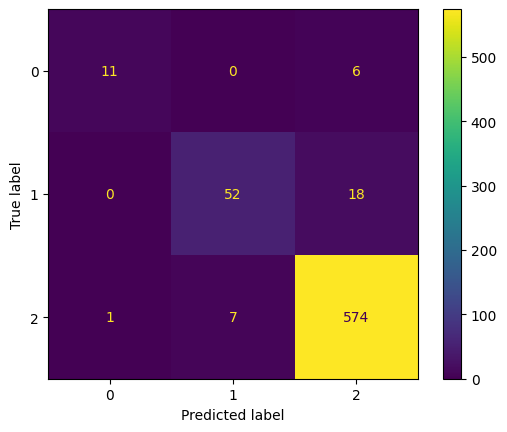

In [34]:
best_r2 = balanced_results_df['r2'].idxmax()
print(f"Best model: {balanced_results_df.iloc[best_r2]['model'].__class__.__name__} with R2={balanced_results_df.iloc[best_r2]['r2']:.4f}")
cm = ConfusionMatrixDisplay(confusion_matrix=balanced_results_df.iloc[best_r2]['confusion_matrix'])
cm.plot()

In [20]:
from sklearn.model_selection import GridSearchCV

random_forest = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'class_weight': [None, 'balanced']
}
clf = GridSearchCV(random_forest, param_grid, cv=5, scoring='r2')
clf.fit(X_train, y_train)
print("Best parameters:", clf.best_params_)
print("Best R2 score:", clf.best_score_)

Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 100}
Best R2 score: 0.10221629644944852
